# Clean Process

이 노트북은 `detail_pages_training_ready.csv` 를 마지막 정리 단계에서 다시 확인하고, 모델 학습 입력용 테이블로 정리합니다.

여기서 수행하는 작업은 다음과 같습니다.

- 기존 training-ready CSV 로드
- `title`, `registration_number` 제거
- canonical identifier tuple 을 앞쪽으로 재배치
- `price_manwon` 을 맨 뒤 target 위치로 이동
- 피처별 분포와 skewness 확인
- 최종 모델 입력 CSV 저장

주의:

- 기존 `detail_pages_training_ready.csv` 는 그대로 둡니다.
- 이 노트북에서 별도 산출물 `detail_pages_model_input.csv` 를 생성합니다.


In [1]:
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display
import sys


ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')
else:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt

plt.style.use('ggplot')


## 1. 경로 설정

현재 작업 디렉터리와 무관하게 프로젝트 루트를 찾고, 입력/출력 경로를 고정합니다.


In [2]:
def find_project_root(start: Path) -> Path:
    for base in (start, *start.parents):
        candidate = base / 'data_collection' / 'clean' / 'output' / 'detail_pages_training_ready.csv'
        if candidate.exists():
            return base
    raise FileNotFoundError('Could not locate project root from the current working directory.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / 'data_collection' / 'clean' / 'output'
TRAINING_READY_CSV = OUTPUT_DIR / 'detail_pages_training_ready.csv'
MODEL_INPUT_CSV = OUTPUT_DIR / 'detail_pages_model_input.csv'
PREPARED_TRAINING_CSV = OUTPUT_DIR / 'prepared_training_1.csv'

print(f'project_root: {PROJECT_ROOT}')
print(f'training_ready_csv: {TRAINING_READY_CSV}')
print(f'model_input_csv: {MODEL_INPUT_CSV}')
print(f'prepared_training_csv: {PREPARED_TRAINING_CSV}')


project_root: /Users/iwonbin/workspace/Study/boot/SKN28-1st-4team
training_ready_csv: /Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/data_collection/clean/output/detail_pages_training_ready.csv
model_input_csv: /Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/data_collection/clean/output/detail_pages_model_input.csv
prepared_training_csv: /Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/data_collection/clean/output/prepared_training_1.csv


## 2. Training-ready 데이터 로드

현재 학습 직전 CSV 를 불러오고 shape, 컬럼, 샘플을 확인합니다.


In [3]:
training_ready_df = pd.read_csv(TRAINING_READY_CSV)

print('shape:', training_ready_df.shape)
print('\ncolumns:')
print(training_ready_df.columns.tolist())
print('\nhead:')
display(training_ready_df.head())


shape: (2131, 12)

columns:
['title', 'registration_number', 'price_manwon', 'model_year', 'first_registration_yyyymm', 'color', 'mileage_km', 'brand', 'model_name', 'trim_name', 'major_category', 'size_score']

head:


,title,registration_number,price_manwon,model_year,first_registration_yyyymm,color,mileage_km,brand,model_name,trim_name,major_category,size_score
0,[현대] 캐스퍼 가솔린 1.0 터보 디 에센셜,197무2382,1780,2023,202304,초록(연두),5770.0,hyundai,캐스퍼,디 에센셜,suv,0.721501
1,[기아] 올 뉴모닝(JA) 가솔린 프레스티지,40라4132,890,2018,201801,검정색,46161.0,kia,올 뉴 모닝 [JA],프레스티지,hatchback,22.797927
2,[KG모빌리티(쌍용)] 코란도 스포츠 CX7 4WD 클럽,89모5254,390,2015,201411,회색,250598.0,kgm,코란도 스포츠,CX7 클럽,truck,32.317073
3,[현대] 코나 1.6 가솔린 2WD 모던 팝,197수6512,1150,2018,201708,"파랑(남색,곤색)",140663.0,hyundai,코나,모던 팝,suv,6.709957
4,[현대] 아반떼AD 1.6 GDi 밸류 플러스,65부3436,970,2018,201709,흰색,117863.0,hyundai,아반떼AD,밸류 플러스,sedan,8.033419


## 3. 최종 컬럼 드롭과 재배치

여기서는 `title`, `registration_number` 를 제거하고, `first_registration_yyyymm` 를 현재 시점 기준 차량 나이(`vehicle_age_years`)로 먼저 변환한 뒤 canonical identifier tuple 을 맨 앞에 둡니다. 마지막에는 `price_manwon` 을 target 컬럼으로 맨 뒤에 둡니다.


In [4]:
DROP_COLUMNS = ['title', 'registration_number']
IDENTIFIER_COLUMNS = ['brand', 'model_name', 'trim_name', 'major_category']
FEATURE_COLUMNS = ['size_score', 'model_year', 'vehicle_age_years', 'color', 'mileage_km']
TARGET_COLUMNS = ['price_manwon']
FINAL_COLUMNS = IDENTIFIER_COLUMNS + FEATURE_COLUMNS + TARGET_COLUMNS

clean_df = training_ready_df.drop(columns=DROP_COLUMNS).copy()
clean_df['first_registration_yyyymm'] = pd.to_numeric(clean_df['first_registration_yyyymm'], errors='coerce')
clean_df['first_registration_date'] = pd.to_datetime(
    clean_df['first_registration_yyyymm'].astype('Int64').astype('string'),
    format='%Y%m',
    errors='coerce',
)
current_timestamp = pd.Timestamp.now().normalize()
current_period = current_timestamp.to_period('M')
registration_period = clean_df['first_registration_date'].dt.to_period('M')
clean_df['vehicle_age_years'] = (
    (current_period - registration_period).apply(lambda period: period.n if pd.notna(period) else None) / 12
).round(2)
clean_df = clean_df.drop(columns=['first_registration_yyyymm', 'first_registration_date'])
clean_df = clean_df[FINAL_COLUMNS].copy()

print(f'current timestamp for vehicle age: {current_timestamp.date()}')
print('final columns:')
print(FINAL_COLUMNS)
print('\nshape after column cleanup:', clean_df.shape)
display(clean_df.head())


current timestamp for vehicle age: 2026-03-17
final columns:
['brand', 'model_name', 'trim_name', 'major_category', 'size_score', 'model_year', 'vehicle_age_years', 'color', 'mileage_km', 'price_manwon']

shape after column cleanup: (2131, 10)


,brand,model_name,trim_name,major_category,size_score,model_year,vehicle_age_years,color,mileage_km,price_manwon
0,hyundai,캐스퍼,디 에센셜,suv,0.721501,2023,2.92,초록(연두),5770.0,1780
1,kia,올 뉴 모닝 [JA],프레스티지,hatchback,22.797927,2018,8.17,검정색,46161.0,890
2,kgm,코란도 스포츠,CX7 클럽,truck,32.317073,2015,11.33,회색,250598.0,390
3,hyundai,코나,모던 팝,suv,6.709957,2018,8.58,"파랑(남색,곤색)",140663.0,1150
4,hyundai,아반떼AD,밸류 플러스,sedan,8.033419,2018,8.50,흰색,117863.0,970


## 4. 최종 모델 입력 CSV 저장

재배치가 끝난 최종 테이블을 별도 파일로 저장합니다.


In [5]:
clean_df.to_csv(MODEL_INPUT_CSV, index=False, encoding='utf-8-sig')

print(f'model input row count: {len(clean_df):,}')
print(f'model input csv saved to: {MODEL_INPUT_CSV}')


model input row count: 2,131
model input csv saved to: /Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/data_collection/clean/output/detail_pages_model_input.csv


## 5. Numeric feature summary 와 skewness 확인

숫자형 피처의 기본 통계량과 skewness 를 확인합니다. 여기서는 `first_registration_yyyymm` 대신 `vehicle_age_years` 를 사용합니다.


In [6]:
numeric_columns = ['size_score', 'model_year', 'vehicle_age_years', 'mileage_km', 'price_manwon']
numeric_summary = clean_df[numeric_columns].describe().T
numeric_summary['skew'] = clean_df[numeric_columns].skew(numeric_only=True)

display(numeric_summary)


,count,mean,std,min,25%,50%,75%,max,skew
size_score,2131.0,51.276470,29.156001,0.00,24.458875,55.487805,75.835476,99.422799,-0.186595
model_year,2131.0,2019.927264,2.864853,2015.00,2018.000000,2020.000000,2022.000000,2026.000000,-0.116788
vehicle_age_years,2131.0,6.233102,2.884392,0.25,3.960000,5.920000,8.670000,12.080000,0.154419
mileage_km,2120.0,90494.629245,53371.312963,1.00,51519.000000,85324.000000,120932.750000,352038.000000,0.904646
price_manwon,2131.0,2047.038480,1356.117576,202.00,1080.000000,1700.000000,2690.000000,16500.000000,2.136544


## 6. Numeric feature distribution plot

숫자형 피처는 컬럼별로 각각 histogram 과 boxplot 을 확인합니다. `size_score` 는 추가로 `major_category` 별 분포를 따로 봅니다.


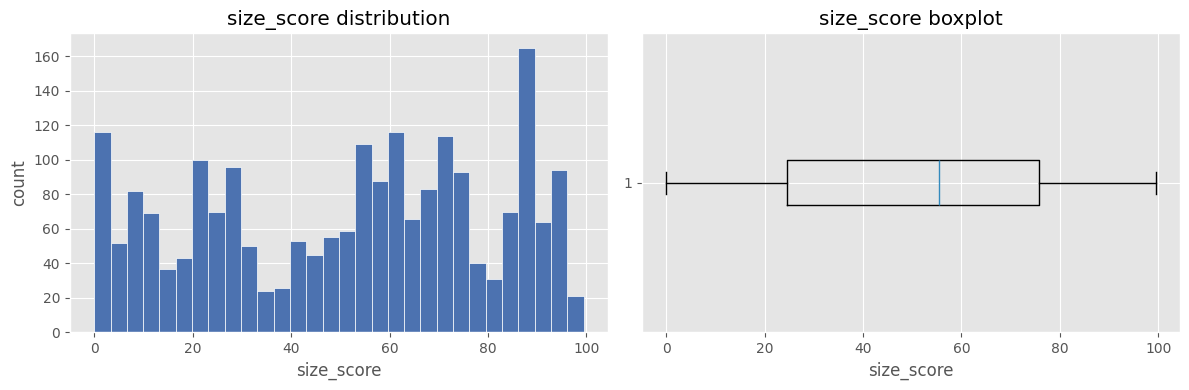

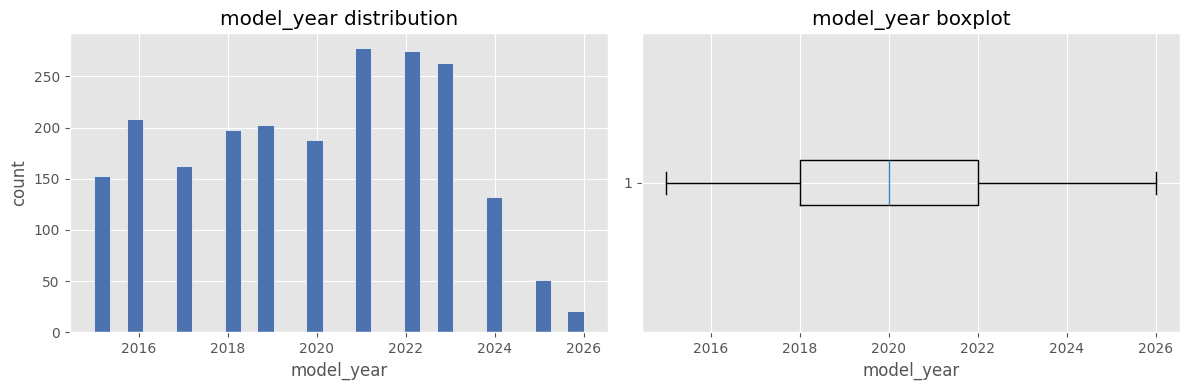

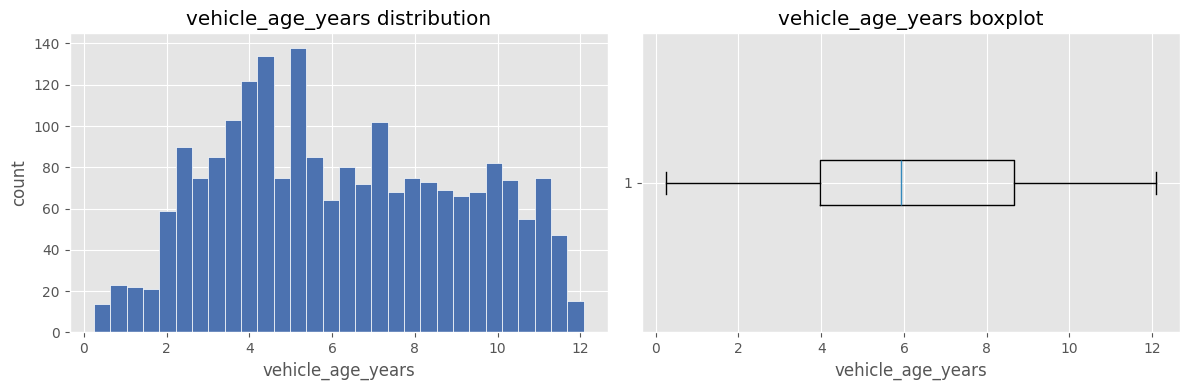

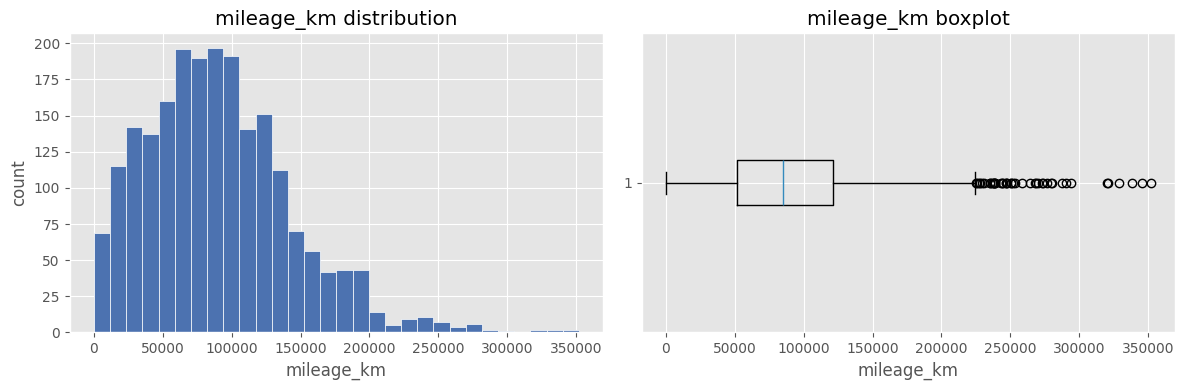

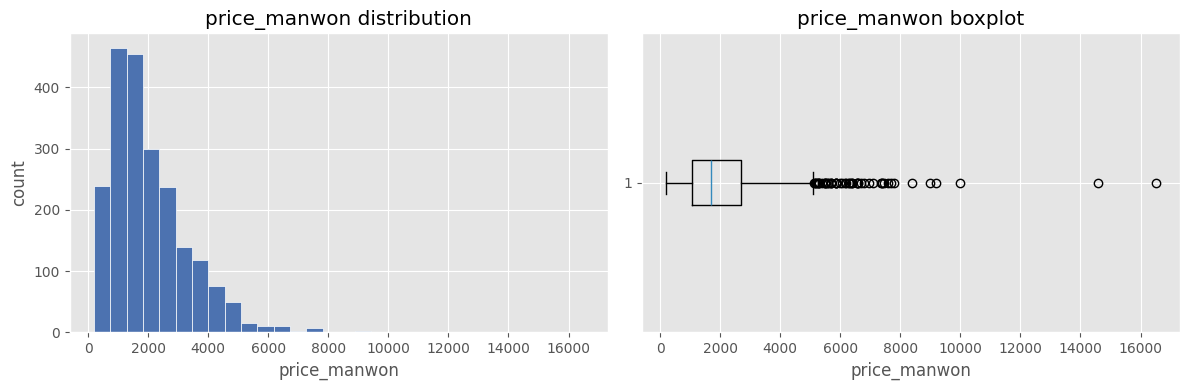

size_score distribution by major_category: coupe_convertible


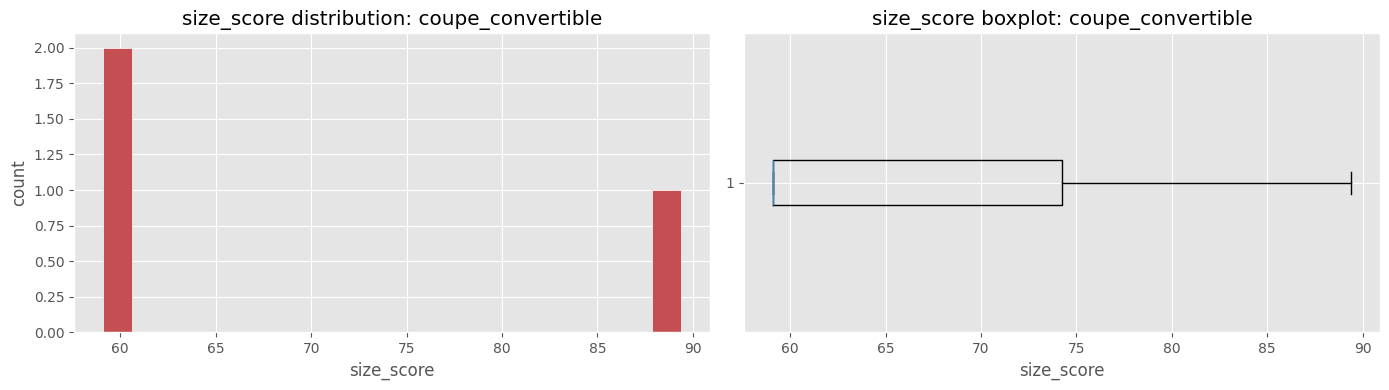

size_score distribution by major_category: hatchback


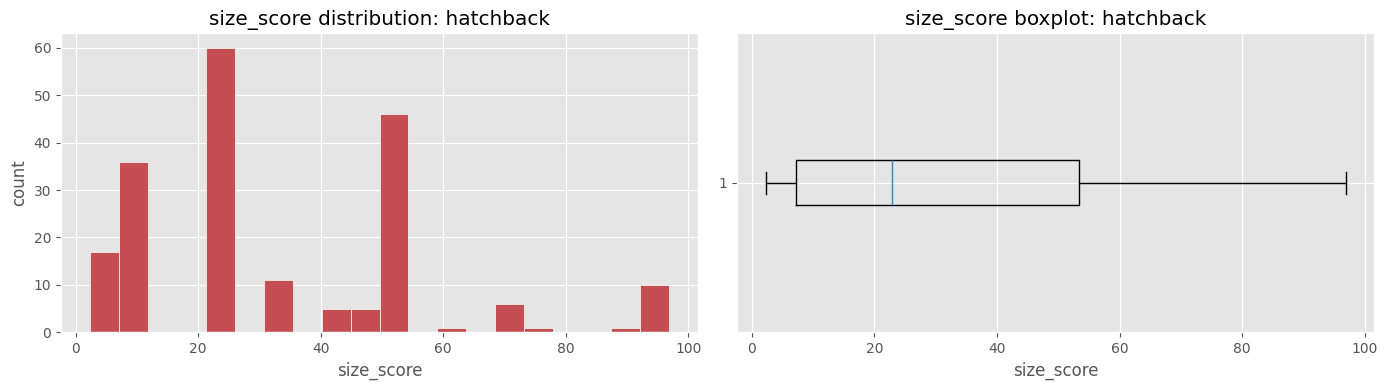

size_score distribution by major_category: sedan


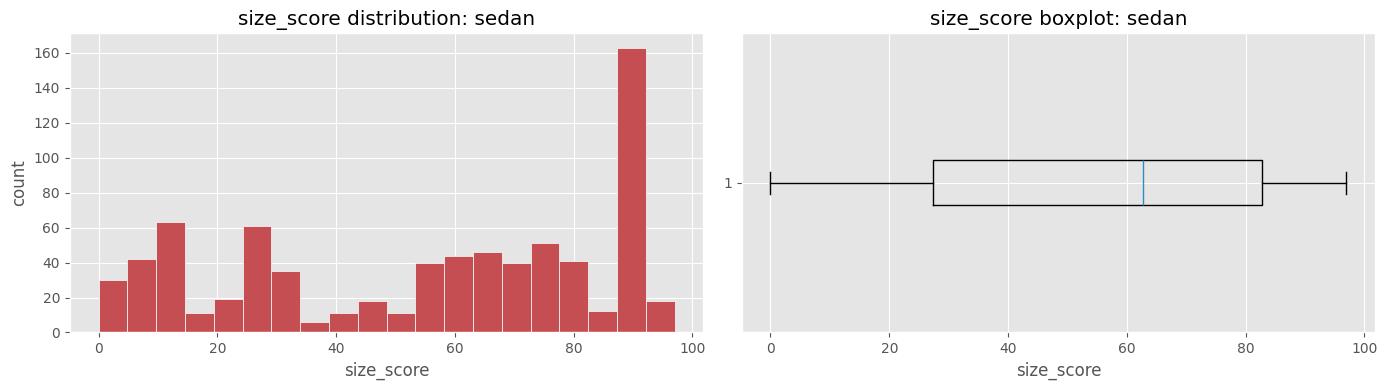

size_score distribution by major_category: suv


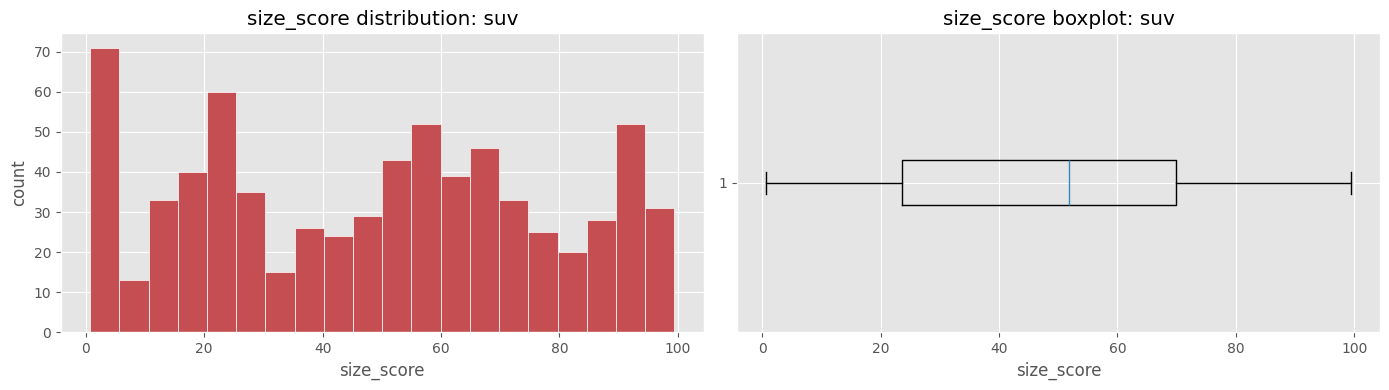

size_score distribution by major_category: truck


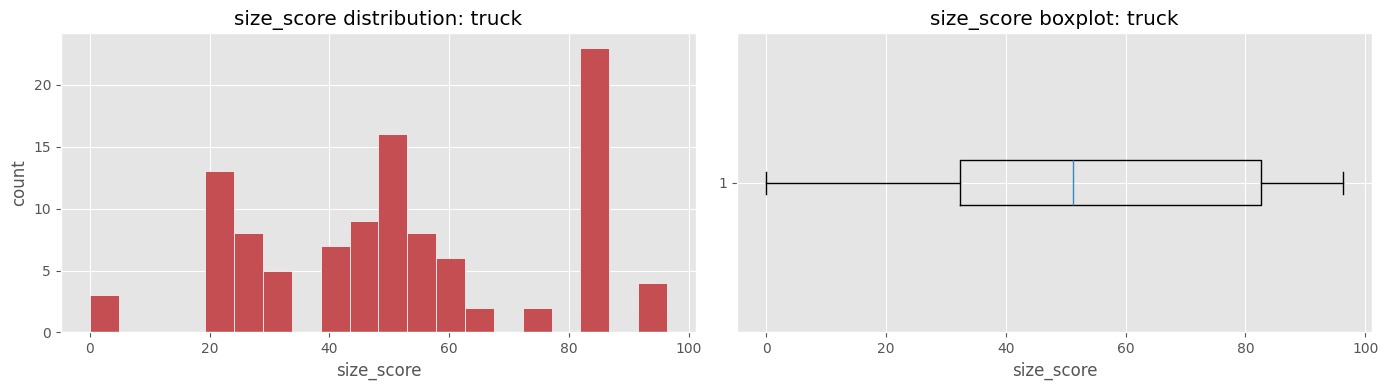

size_score distribution by major_category: unknown


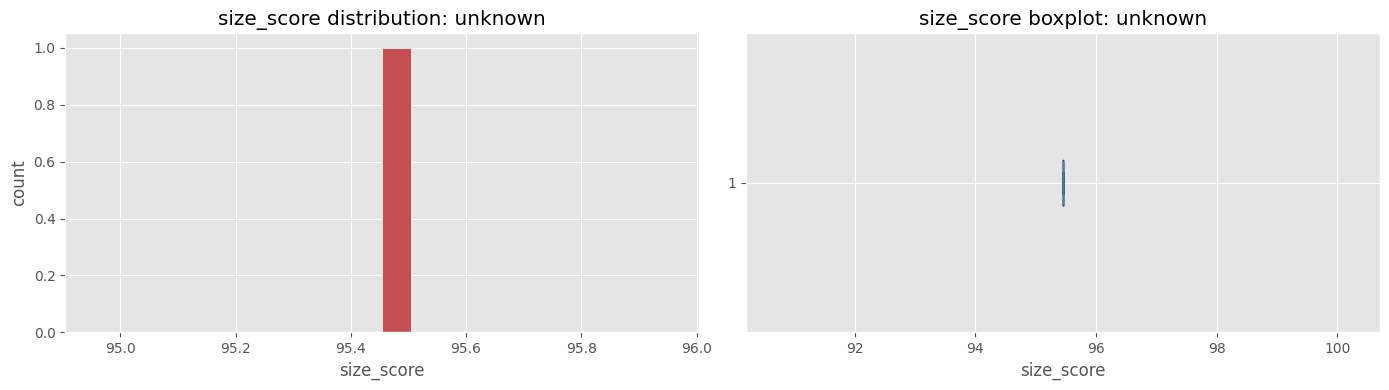

size_score distribution by major_category: van


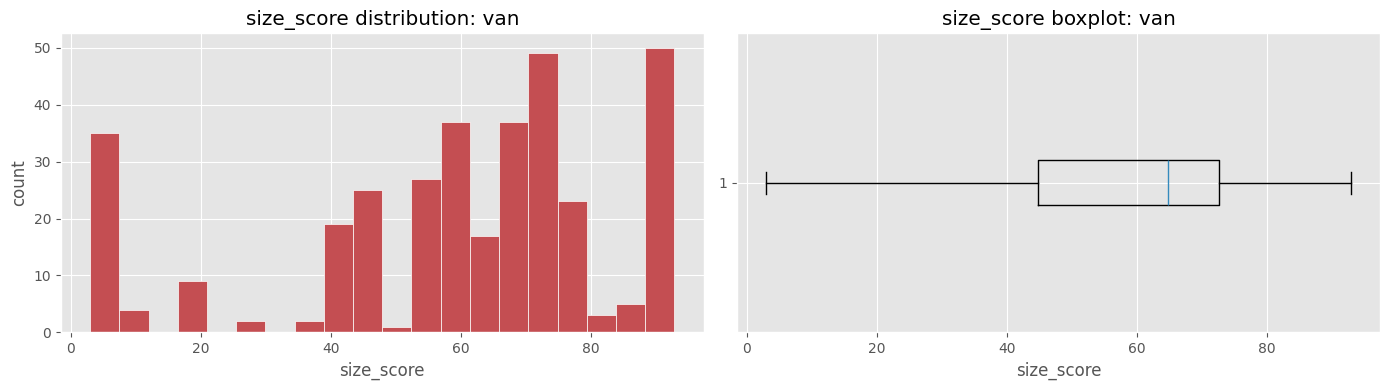

,count,mean,std,min,25%,50%,75%,max
major_category,,,,,,,,
coupe_convertible,3.0,69.192,17.495,59.091,59.091,59.091,74.242,89.394
hatchback,199.0,33.040,24.808,2.332,7.254,22.798,53.368,96.891
sedan,762.0,54.971,30.107,0.000,27.378,62.725,82.776,96.979
suv,715.0,48.296,29.097,0.722,23.593,51.804,69.841,99.423
truck,106.0,53.331,24.142,0.000,32.317,51.220,82.622,96.341
unknown,1.0,95.455,NaN,95.455,95.455,95.455,95.455,95.455
van,345.0,58.899,25.651,3.005,44.809,64.754,72.678,92.896


In [7]:
for column in numeric_columns:
    series = clean_df[column].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(series, bins=30, color='#4C72B0', edgecolor='white')
    axes[0].set_title(f'{column} distribution')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('count')
    axes[1].boxplot(series, vert=False)
    axes[1].set_title(f'{column} boxplot')
    axes[1].set_xlabel(column)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

size_score_by_category = clean_df[['major_category', 'size_score']].dropna().copy()
category_order = sorted(size_score_by_category['major_category'].unique())
for category in category_order:
    category_scores = size_score_by_category.loc[
        size_score_by_category['major_category'] == category,
        'size_score',
    ]
    print(f'size_score distribution by major_category: {category}')
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(category_scores, bins=20, color='#C44E52', edgecolor='white')
    axes[0].set_title(f'size_score distribution: {category}')
    axes[0].set_xlabel('size_score')
    axes[0].set_ylabel('count')
    axes[1].boxplot(category_scores, vert=False)
    axes[1].set_title(f'size_score boxplot: {category}')
    axes[1].set_xlabel('size_score')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

size_score_category_summary = size_score_by_category.groupby('major_category')['size_score'].describe().round(3)
display(size_score_category_summary)


## 7. Categorical feature distribution plot

범주형 피처는 컬럼별로 각각 분포를 그리고, 그래프 아래에 값과 빈도 표를 함께 보여줍니다. 모델명, 트림명, 카테고리, 색상은 한글 라벨이 깨져도 표로 바로 확인할 수 있게 합니다.


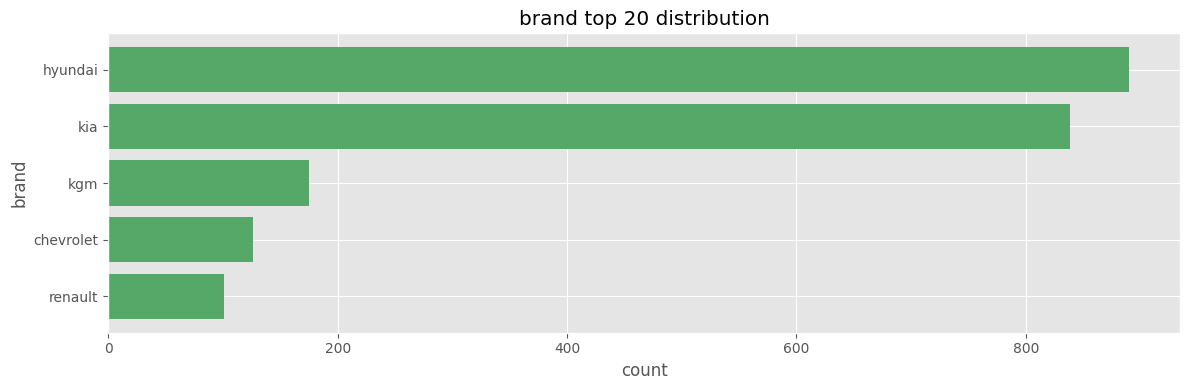

brand frequency table (sorted by value):


,value,count
0,chevrolet,126
1,hyundai,890
2,kgm,175
3,kia,839
4,renault,101


/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 49472 (\N{HANGUL SYLLABLE SEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 50732 (\N{HANGUL SYLLABLE OL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_413

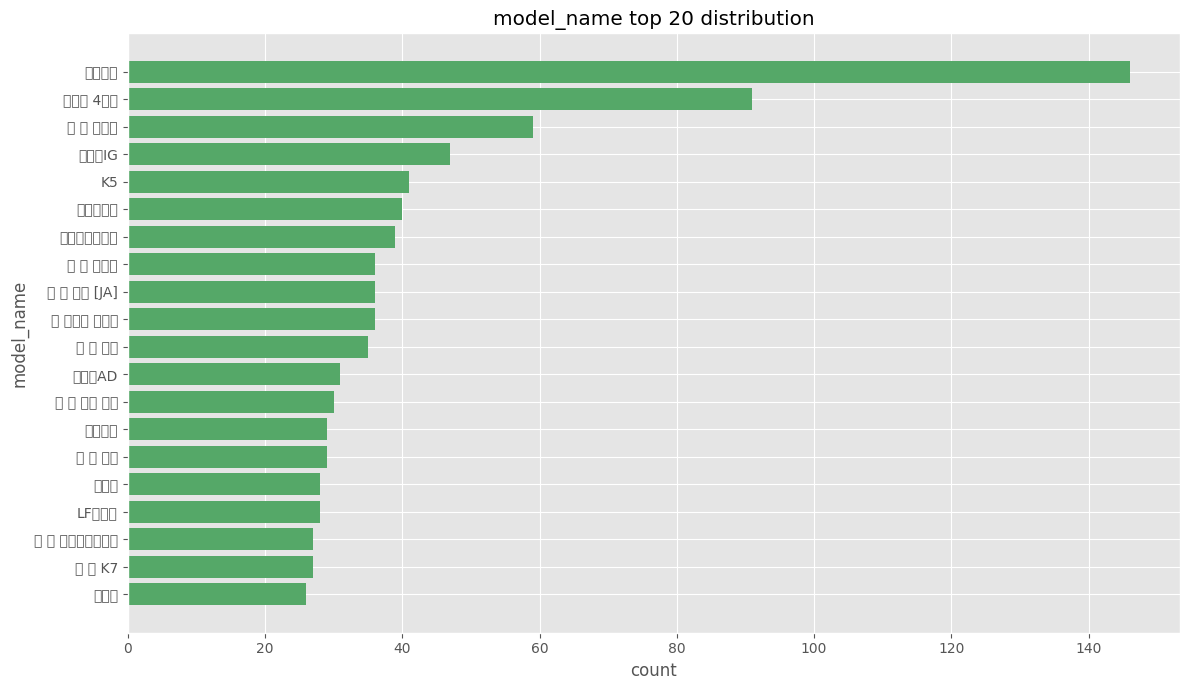

model_name frequency table (sorted by value):


,value,count
0,G4 렉스턴,5
1,K3,7
2,K5,41
3,K5 하이브리드,9
4,K7 프리미어,6
...,...,...
177,트레일블레이저,5
178,티볼리,14
179,티볼리 아머,10
180,티볼리 에어,13


/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel

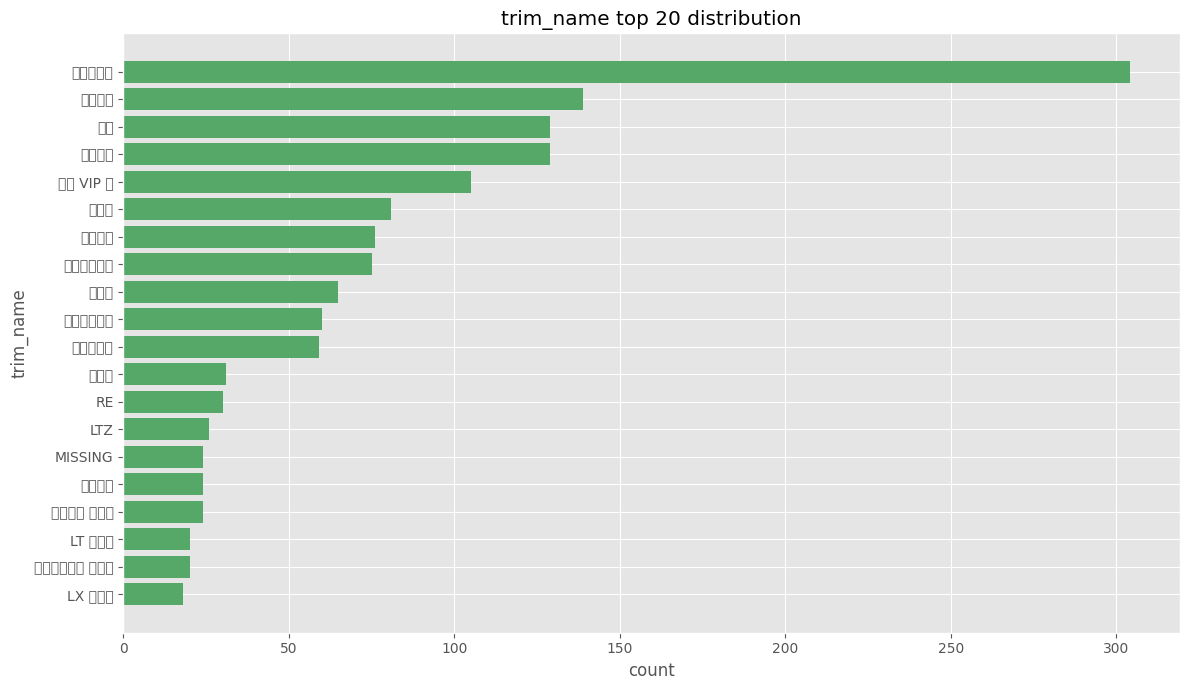

trim_name frequency table (sorted by value):


,value,count
0,11인승,6
1,12인승,2
2,15인승,1
3,2WD,2
4,4WD,4
...,...,...
197,플래티넘Ⅲ,4
198,플럭스,4
199,필,2
200,하이루프 특장차,2


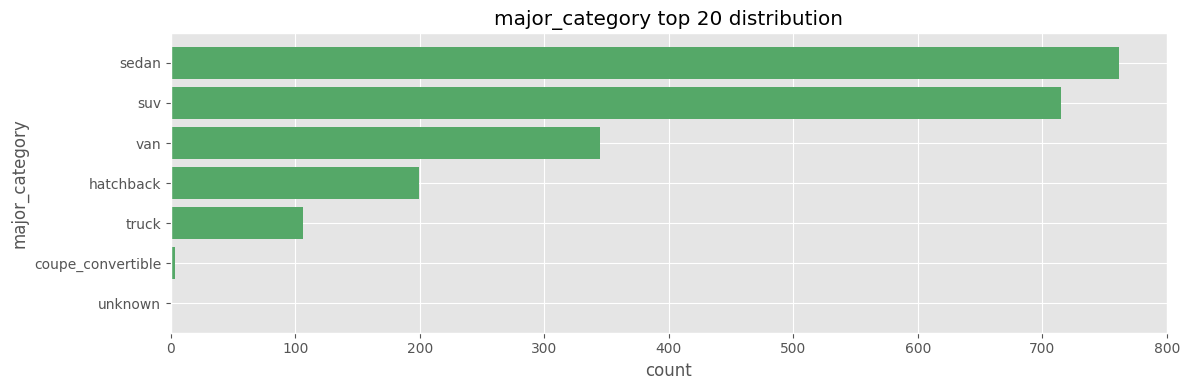

major_category frequency table (sorted by value):


,value,count
0,coupe_convertible,3
1,hatchback,199
2,sedan,762
3,suv,715
4,truck,106
5,unknown,1
6,van,345


/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 44620 (\N{HANGUL SYLLABLE GGA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/577263729.py:19: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_41378/

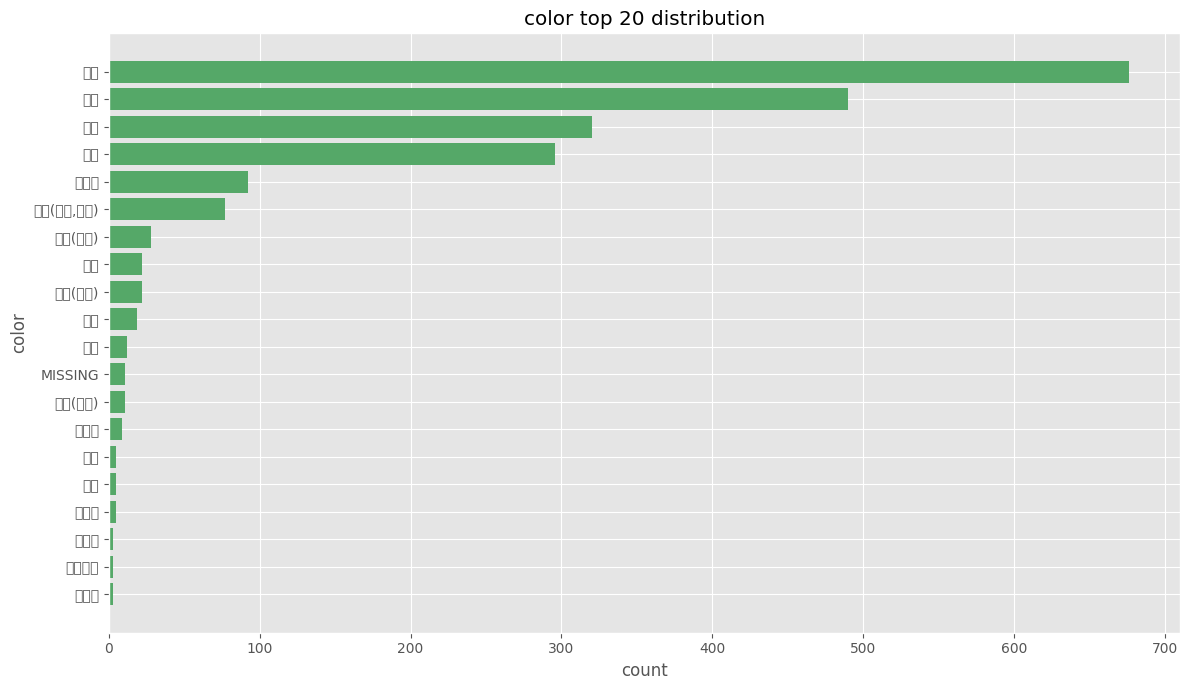

color frequency table (sorted by value):


,value,count
0,MISSING,11
1,갈색,2
2,갈색(밤색),11
3,검정,320
4,검정색,92
5,검정투톤,3
6,곤색,1
7,국방색,1
8,군청색,1
9,까치투톤,3


In [8]:
categorical_columns = ['brand', 'model_name', 'trim_name', 'major_category', 'color']

for column in categorical_columns:
    frequency_table = (
        clean_df[column]
        .fillna('MISSING')
        .astype(str)
        .value_counts()
        .rename_axis('value')
        .reset_index(name='count')
    )
    top_counts = frequency_table.head(20).sort_values('count')

    fig, ax = plt.subplots(figsize=(12, max(4, len(top_counts) * 0.35)))
    ax.barh(top_counts['value'], top_counts['count'], color='#55A868')
    ax.set_title(f'{column} top 20 distribution')
    ax.set_xlabel('count')
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print(f'{column} frequency table (sorted by value):')
    display(frequency_table.sort_values('value').reset_index(drop=True))


## 8. 후속 작업 메모

이 노트북 결과를 기반으로 다음 단계에서 판단할 수 있는 항목은 다음과 같습니다.

- `vehicle_age_years`, `mileage_km`, `price_manwon` 에 clipping 이 필요한지 여부
- `size_score` 가 `major_category` 별로 충분히 고르게 분포하는지 여부
- `color`, `model_name`, `trim_name` 의 high-cardinality 처리 방식
- 최종 모델 학습에 사용할 feature set 확정


## 9. Final Export

최종 학습 준비 데이터셋을 `prepared_training_1.csv` 로 저장하고, 컬럼명과 샘플 5개를 확인합니다.


In [9]:
prepared_training_df = clean_df[FINAL_COLUMNS].copy()
prepared_training_df.to_csv(PREPARED_TRAINING_CSV, index=False, encoding='utf-8-sig')

print(f'prepared training row count: {len(prepared_training_df):,}')
print(f'prepared training csv saved to: {PREPARED_TRAINING_CSV}')
print('\nprepared training columns:')
print(prepared_training_df.columns.tolist())
print('\nprepared training head:')
display(prepared_training_df.head())


prepared training row count: 2,131
prepared training csv saved to: /Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/data_collection/clean/output/prepared_training_1.csv

prepared training columns:
['brand', 'model_name', 'trim_name', 'major_category', 'size_score', 'model_year', 'vehicle_age_years', 'color', 'mileage_km', 'price_manwon']

prepared training head:


,brand,model_name,trim_name,major_category,size_score,model_year,vehicle_age_years,color,mileage_km,price_manwon
0,hyundai,캐스퍼,디 에센셜,suv,0.721501,2023,2.92,초록(연두),5770.0,1780
1,kia,올 뉴 모닝 [JA],프레스티지,hatchback,22.797927,2018,8.17,검정색,46161.0,890
2,kgm,코란도 스포츠,CX7 클럽,truck,32.317073,2015,11.33,회색,250598.0,390
3,hyundai,코나,모던 팝,suv,6.709957,2018,8.58,"파랑(남색,곤색)",140663.0,1150
4,hyundai,아반떼AD,밸류 플러스,sedan,8.033419,2018,8.50,흰색,117863.0,970
